In [5]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [6]:
df = pd.read_csv("Fish.csv")
df

,Species,Weight,Length1,Length2,Length3,Height,Width
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340
...,...,...,...,...,...,...,...
154,Smelt,12.2,11.5,12.2,13.4,2.0904,1.3936
155,Smelt,13.4,11.7,12.4,13.5,2.4300,1.2690
156,Smelt,12.2,12.1,13.0,13.8,2.2770,1.2558
157,Smelt,19.7,13.2,14.3,15.2,2.8728,2.0672


# Simple Linear Regression

In [10]:
df.isna().sum()

Species    0
Weight     0
Length1    0
Length2    0
Length3    0
Height     0
Width      0
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(0)

<Axes: >

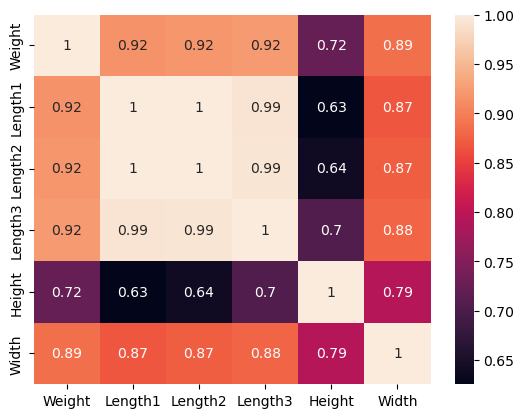

In [14]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

<Axes: xlabel='Length1', ylabel='Weight'>

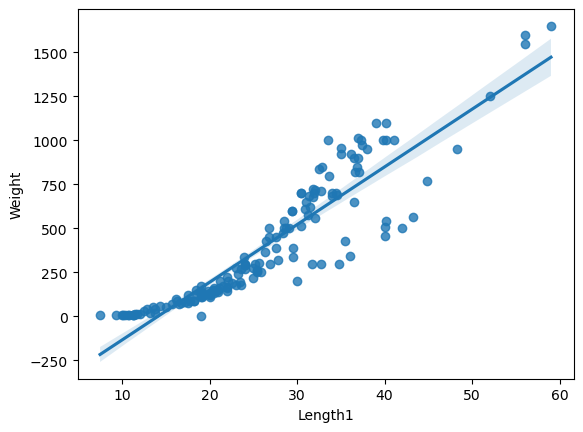

In [16]:
sns.regplot(df,x="Length1",y="Weight")

# Predicting weight from length 1

In [23]:
x=df[["Length1"]]
y=df[["Weight"]]

In [25]:
x,y

(     Length1
 0       23.2
 1       24.0
 2       23.9
 3       26.3
 4       26.5
 ..       ...
 154     11.5
 155     11.7
 156     12.1
 157     13.2
 158     13.8
 
 [159 rows x 1 columns],
      Weight
 0     242.0
 1     290.0
 2     340.0
 3     363.0
 4     430.0
 ..      ...
 154    12.2
 155    13.4
 156    12.2
 157    19.7
 158    19.9
 
 [159 rows x 1 columns])

# Divide the Data in 2 Parts : Training and Testing  

In [26]:
from sklearn.model_selection import train_test_split

In [27]:
train_test_split

<function sklearn.model_selection._split.train_test_split(*arrays, test_size=None, train_size=None, random_state=None, shuffle=True, stratify=None)>

In [29]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [33]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(127, 1)
(32, 1)
(127, 1)
(32, 1)


# Build a Model

In [34]:
from sklearn.linear_model import LinearRegression

In [35]:
model = LinearRegression()

In [36]:
model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [37]:
model.coef_ # m

array([[32.44308998]])

In [40]:
model.intercept_ # c

array([-464.13411601])

In [54]:
y_pred = model.predict(X_test)
y_pred

array([[  80.9097957 ],
       [ -84.54996321],
       [ 509.15858348],
       [ 301.52280759],
       [ 217.17077363],
       [ 622.70939842],
       [-136.45890718],
       [ 301.52280759],
       [ 269.07971761],
       [1222.9065631 ],
       [ 541.60167346],
       [ 745.99314035],
       [ 489.69272949],
       [ 132.81873968],
       [ 570.80045445],
       [ 671.37403339],
       [ 840.0781013 ],
       [ 346.94313356],
       [ 249.61386362],
       [ 522.13581947],
       [ -97.5271992 ],
       [ 538.35736446],
       [ 479.95980249],
       [ 460.4939485 ],
       [ 671.37403339],
       [ 836.83379231],
       [ 233.39231862],
       [ 317.74435258],
       [-162.41337917],
       [ -97.5271992 ],
       [ 833.58948331],
       [  45.22239672]])

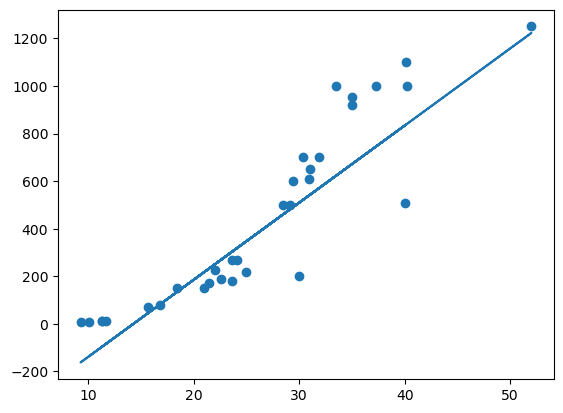

In [50]:
plt.plot(X_test,y_pred)    # Predicted Line
plt.scatter(X_test,y_test) # Actual Points

In [52]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [53]:
print(mean_absolute_error(y_test,y_pred))
print(mean_squared_error(y_test,y_pred))
print(r2_score(y_test,y_pred))

129.36788419512138
26796.684740821387
0.8116084146869396


In [59]:
# what will be the weight if length is 25?
model.predict(np.array([[25]]))

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([[346.94313356]])

# Predicting weight from length1, length2, length3, height and width

In [85]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [115]:
df = pd.read_csv('Fish.csv')
x = df.drop(['Species','Weight'],axis=1)
y = df[['Weight']]
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=40)
model=LinearRegression()
model.fit(x_train,y_train)
y_pred = model.predict(x_test)
print(mean_absolute_error(y_test,y_pred))
print(mean_squared_error(y_test,y_pred))
print(r2_score(y_test,y_pred))

109.0632714203943
21303.013279012113
0.8679594534557271


In [113]:
df = pd.read_csv('Fish.csv')
x = df.drop(['Species','Weight'],axis=1)
y = df[['Weight']]
test = [0.75,0.8,0.85,0.9,0.95]
mse=[]
r2=[]
for i in test:
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=i, random_state=40)
    model=LinearRegression()
    model.fit(x_train,y_train)
    y_pred = model.predict(x_test)

    mse.append(mean_squared_error(y_test,y_pred))
    r2.append(r2_score(y_test,y_pred))
    
print(mse)
print(r2)

[21485.14792353189, 19141.389851256346, 24762.671477245258, 20643.648028028125, 48861.047183691735]
[0.8482152077173417, 0.8607660310160297, 0.8173371854115964, 0.8468087122619059, 0.6289837470636086]


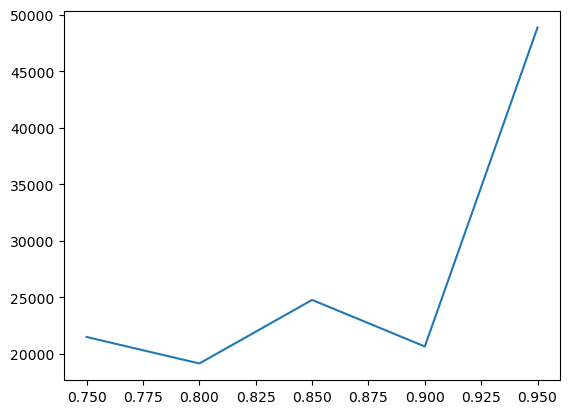

In [89]:
plt.plot(test,mse)

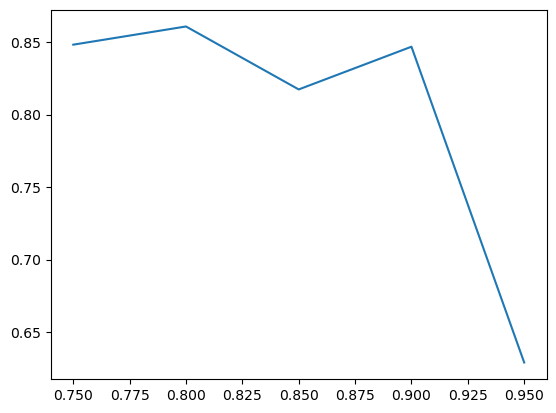

In [90]:
plt.plot(test,r2)

# Predict weight when other parameters are 10

In [103]:
df = pd.read_csv('Fish.csv')
x = df.drop(['Species','Weight'],axis=1)
y = df[['Weight']]
test = [0.75,0.8,0.85,0.9,0.95]
mse=[]
r2=[]
for i in test:
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=i, random_state=40)
    model=LinearRegression()
    model.fit(x_train,y_train)
    y_pred = model.predict(x_test)

    mse.append(mean_squared_error(y_test,y_pred))
    r2.append(r2_score(y_test,y_pred))

    print(model.predict(np.array([[10,10,10,10,10]])))

[[625.82515147]]
[[502.4333856]]
[[935.26653348]]
[[74.46155573]]
[[629.13953432]]


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [119]:
df = pd.read_csv("Ice_cream selling data.csv")
df.head()

,Temperature (°C),Ice Cream Sales (units)
0,-4.662263,41.842986
1,-4.316559,34.661120
2,-4.213985,39.383001
3,-3.949661,37.539845
4,-3.578554,32.284531


In [107]:
df.isna().sum()

Temperature (°C)           0
Ice Cream Sales (units)    0
dtype: int64

In [109]:
df.duplicated().sum()

np.int64(0)

In [110]:
df.columns

Index(['Temperature (°C)', 'Ice Cream Sales (units)'], dtype='object')

In [120]:
x = df[["Temperature (°C)"]]
y = df[["Ice Cream Sales (units)"]]
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=40)
model=LinearRegression()
model.fit(x_train,y_train)
y_pred = model.predict(x_test)
print(mean_absolute_error(y_test,y_pred))
print(mean_squared_error(y_test,y_pred))
print(r2_score(y_test,y_pred))

14.28681469049703
288.6596992061606
-0.4122082415321706


<Axes: xlabel='Temperature (°C)', ylabel='Ice Cream Sales (units)'>

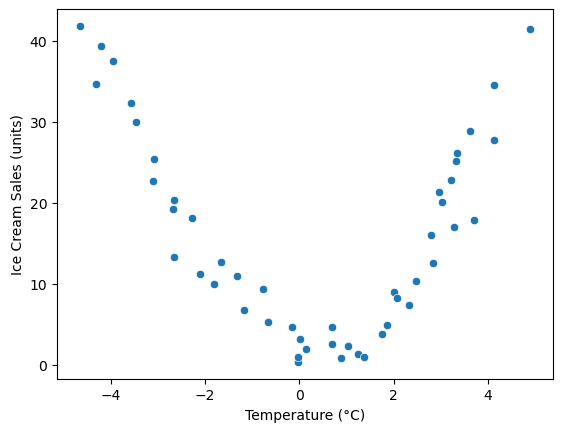

In [121]:
sns.scatterplot(df,x="Temperature (°C)",y='Ice Cream Sales (units)')

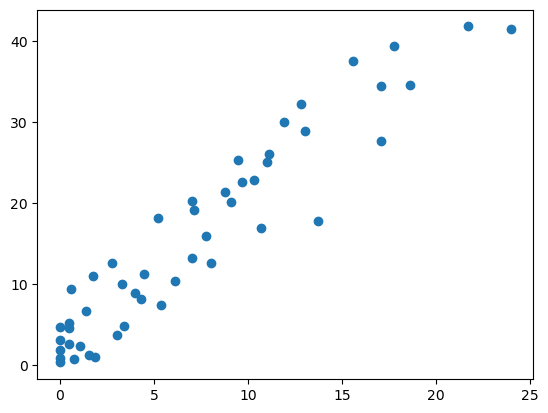

In [124]:
plt.scatter(df["Temperature (°C)"]*df["Temperature (°C)"],df["Ice Cream Sales (units)"])